In [1]:
# Force widget backend BEFORE any hyperspy/matplotlib imports
# This must be the very first cell run after a kernel restart
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')  # reset any cached backend

%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
import hyperspy.api as hs
import lumispy as lum
from h5py import File

# Tell HyperSpy explicitly to use the widget toolkit
hs.preferences.GUIs.warn_if_guis_are_not_installed = False
hs.preferences.Plot.widget_plot_style = 'horizontal'

import matplotlib
print(f'Backend active: {matplotlib.get_backend()}')
print('✅ If backend shows module://ipympl... the slider will work inline.')
print('⚠️  If backend shows Qt, run: pip install ipympl --upgrade, then restart kernel.')


C:\Users\jonny\anaconda3\envs\HyperSpy\Lib\site-packages\rsciio\utils\tools.py:93: VisibleDeprecationWarning: append2pathname has been moved to `rsciio.utils.path` and will be removed from `rsciio.utils.tools` in version 1.0.
  warnings.warn(message, VisibleDeprecationWarning)
C:\Users\jonny\anaconda3\envs\HyperSpy\Lib\site-packages\rsciio\utils\tools.py:93: VisibleDeprecationWarning: incremental_filename has been moved to `rsciio.utils.path` and will be removed from `rsciio.utils.tools` in version 1.0.
  warnings.warn(message, VisibleDeprecationWarning)
C:\Users\jonny\anaconda3\envs\HyperSpy\Lib\site-packages\rsciio\utils\tools.py:93: VisibleDeprecationWarning: get_file_handle has been moved to `rsciio.utils.file` and will be removed from `rsciio.utils.tools` in version 1.0.
  warnings.warn(message, VisibleDeprecationWarning)
C:\Users\jonny\anaconda3\envs\HyperSpy\Lib\site-packages\rsciio\utils\rgb_tools.py:46: VisibleDeprecationWarning: The module `rsciio.utils.rgb_tools` has been re

Backend active: widget
✅ If backend shows module://ipympl... the slider will work inline.
⚠️  If backend shows Qt, run: pip install ipympl --upgrade, then restart kernel.


In [2]:
def load_map(file_path, dataset_path):
    r''' Loads numpy array from .h5 delmic file.
    file path - location of .h5
    dataset_path - location of 
    '''
    with File(file_path, 'r') as f:
        data = f[dataset_path][()]  
    return data

In [3]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import hyperspy.api as hs
import pandas as pd
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
import os
from datetime import datetime
import tkinter as tk
from tkinter import filedialog
import ipywidgets as widgets
from IPython.display import display

warnings.filterwarnings('ignore', module='rsciio')

# Default base directories
RAW_DATA_DIR       = r'C:\Users\jonny\Lehigh University Dropbox\ENG-MATSGroup\MATS\Data\Raw - Data'
LITERATURE_DIR     = r'C:\Users\jonny\Lehigh University Dropbox\ENG-MATSGroup\MATS\Data\Parsers\PeakSeek\Literature Data'
OUTPUT_DIR         = r'C:\Users\jonny\Lehigh University Dropbox\ENG-MATSGroup\MATS\Data\Processed - Sample'

# Shared state — these get populated by the file dialogs below
selected_files = {
    'data':    None,
    'literature': None,
    'output_dir': OUTPUT_DIR,
}

# --- Helper: open a tkinter dialog without showing the root window ---
def _tk_dialog(func, **kwargs):
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    result = func(**kwargs)
    root.destroy()
    return result

# --- Labels showing current selections ---
data_label = widgets.Label(value='No file selected')
lit_label  = widgets.Label(value='No file selected')
out_label  = widgets.Label(value=OUTPUT_DIR)

# --- Buttons ---
btn_data = widgets.Button(
    description='Browse Raw Data (.h5)',
    button_style='primary',
    layout=widgets.Layout(width='220px')
)
btn_lit = widgets.Button(
    description='Browse Literature (.xlsx)',
    button_style='primary',
    layout=widgets.Layout(width='220px')
)
btn_out = widgets.Button(
    description='Browse Output Folder',
    button_style='warning',
    layout=widgets.Layout(width='220px')
)
btn_confirm = widgets.Button(
    description='✅ Confirm & Load Data',
    button_style='success',
    layout=widgets.Layout(width='220px')
)
status_label = widgets.Label(value='')

def on_browse_data(b):
    path = _tk_dialog(
        filedialog.askopenfilename,
        title='Select Raw CL/PL Data File',
        initialdir=RAW_DATA_DIR,
        filetypes=[('HDF5 files', '*.h5'), ('All files', '*.*')]
    )
    if path:
        selected_files['data'] = path
        data_label.value = os.path.basename(path)

def on_browse_lit(b):
    path = _tk_dialog(
        filedialog.askopenfilename,
        title='Select Literature Peaks File',
        initialdir=LITERATURE_DIR,
        filetypes=[('Excel files', '*.xlsx *.xls'), ('All files', '*.*')]
    )
    if path:
        selected_files['literature'] = path
        lit_label.value = os.path.basename(path)

def on_browse_out(b):
    folder = _tk_dialog(
        filedialog.askdirectory,
        title='Select Output Folder',
        initialdir=OUTPUT_DIR,
    )
    if folder:
        selected_files['output_dir'] = folder
        out_label.value = folder

def on_confirm(b):
    if not selected_files['data']:
        status_label.value = '⚠️  Please select a raw data file first.'
        return
    if not selected_files['literature']:
        status_label.value = '⚠️  Please select a literature peaks file first.'
        return

    # Load data and store everything in selected_files dict
    # (avoids unreliable global assignment from within widget callbacks)
    try:
        selected_files['raw_data'] = load_map(selected_files['data'], 'Acquisition2/ImageData/Image')
        selected_files['data_squeezed'] = selected_files['raw_data'].squeeze()
        selected_files['confirmed'] = True
        status_label.value = (
            f"✅ Loaded: {os.path.basename(selected_files['data'])}  |  "
            f"Literature: {os.path.basename(selected_files['literature'])}  |  "
            f"Output: {selected_files['output_dir']}"
        )
    except Exception as e:
        status_label.value = f'❌ Error loading data: {e}'

btn_data.on_click(on_browse_data)
btn_lit.on_click(on_browse_lit)
btn_out.on_click(on_browse_out)
btn_confirm.on_click(on_confirm)

# --- Layout ---
display(widgets.HTML('<b>── Input Files ──────────────────────────────</b>'))
display(widgets.HBox([btn_data, data_label]))
display(widgets.HBox([btn_lit,  lit_label]))
display(widgets.HTML('<b>── Output Folder ────────────────────────────</b>'))
display(widgets.HBox([btn_out,  out_label]))
display(widgets.HTML('<b>─────────────────────────────────────────────</b>'))
display(btn_confirm)
display(status_label)


HTML(value='<b>── Input Files ──────────────────────────────</b>')

HTML(value='<b>── Output Folder ────────────────────────────</b>')

HTML(value='<b>─────────────────────────────────────────────</b>')

Button(button_style='success', description='✅ Confirm & Load Data', layout=Layout(width='220px'), style=Button…

Label(value='')

✅ Using data:       240326TE_S2_CL_5kV_1p6nA_1200_8K_004.h5
✅ Using literature: 260326TE_S2_005_peaks_260310.xlsx
✅ Output folder:    C:/Users/jonny/Lehigh University Dropbox/ENG-MATSGroup/MATS/Data/Processed - Sample/24/2403/240326TE_S2/CL - Delmic/PeakSeek/240326TE_S2_CL_5kV_1p6nA_1200_8K_004


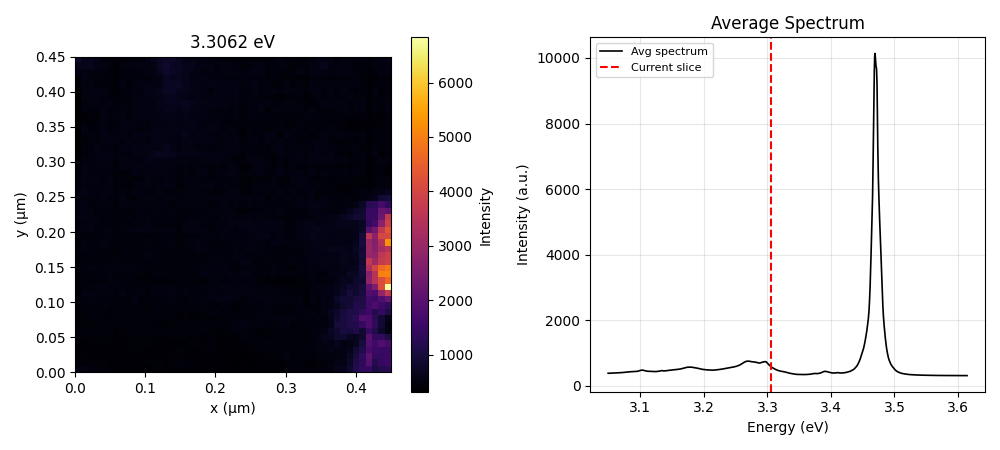

Drag the slider or type an exact eV value and press Enter. Click 💾 Save Explorer to export the current view — press multiple times for multiple saves.


In [4]:
# --- GUARD: ensure files have been selected and confirmed in Cell 2 ---
if not selected_files.get('confirmed'):
    raise RuntimeError('⚠️  Please run Cell 2 and click "✅ Confirm & Load Data" first.')

# Assign from selected_files dict — reliable across Jupyter cells
path       = selected_files['data']
excel_path = selected_files['literature']
output_dir = selected_files['output_dir']
raw_data   = selected_files['raw_data']
data       = selected_files['data_squeezed']

print(f'✅ Using data:       {os.path.basename(path)}')
print(f'✅ Using literature: {os.path.basename(excel_path)}')
print(f'✅ Output folder:    {output_dir}')

import ipywidgets as widgets
from IPython.display import display

# --- BUILD DATA CUBE ---
hc = 1239.84193
wavelengths = load_map(path, 'Acquisition2/ImageData/DimensionScaleC') * 1e9
energy_axis = np.sort(hc / wavelengths)

data_work = raw_data.squeeze()
if data_work.shape[-1] > data_work.shape[0]:
    data_work = data_work.transpose(2, 0, 1)
data_work = np.flip(data_work, axis=0).copy()  # shape: (energy, y, x)

avg_spectrum = np.mean(data_work, axis=(1, 2))

# --- FIGURE ---
fig_explore, (ax_map, ax_spec) = plt.subplots(1, 2, figsize=(10, 4.5))
plt.subplots_adjust(wspace=0.35)

n_energies = data_work.shape[0]
init_idx = n_energies // 2
init_ev  = float(energy_axis[init_idx])

# Left panel: spatial map
im = ax_map.imshow(
    data_work[init_idx],
    origin='lower',
    extent=[0, data_work.shape[2] * 0.009,
            0, data_work.shape[1] * 0.009],
    cmap='inferno'
)
map_title = ax_map.set_title(f'{init_ev:.4f} eV')
ax_map.set_xlabel('x (μm)')
ax_map.set_ylabel('y (μm)')
plt.colorbar(im, ax=ax_map, label='Intensity')

# Right panel: average spectrum + tracking line
ax_spec.plot(energy_axis, avg_spectrum, color='black', linewidth=1.2, label='Avg spectrum')
vline = ax_spec.axvline(x=init_ev, color='red', linewidth=1.5, linestyle='--', label='Current slice')
ax_spec.set_xlabel('Energy (eV)')
ax_spec.set_ylabel('Intensity (a.u.)')
ax_spec.set_title('Average Spectrum')
ax_spec.legend(fontsize=8)
ax_spec.grid(True, alpha=0.3)
plt.tight_layout()

# --- UPDATE FUNCTION ---
# Snaps requested eV to nearest real axis value and updates both panels
_updating = False  # guard to prevent slider and text box triggering each other

def update_map(ev):
    idx = int(np.argmin(np.abs(energy_axis - ev)))
    snapped_ev = float(energy_axis[idx])
    im.set_data(data_work[idx])
    im.set_clim(vmin=data_work[idx].min(), vmax=data_work[idx].max())
    map_title.set_text(f'{snapped_ev:.4f} eV')
    vline.set_xdata([snapped_ev, snapped_ev])
    fig_explore.canvas.draw_idle()
    return snapped_ev

# --- SLIDER ---
slider = widgets.SelectionSlider(
    options=[(f'{ev:.4f} eV', float(ev)) for ev in energy_axis],
    value=init_ev,
    description='Energy:',
    continuous_update=True,
    layout=widgets.Layout(width='600px')
)

# --- TEXT BOX ---
# User types an exact eV value and presses Enter — snaps to nearest measured energy
text_box = widgets.BoundedFloatText(
    value=init_ev,
    min=float(energy_axis.min()),
    max=float(energy_axis.max()),
    step=0.0001,
    description='Go to eV:',
    continuous_update=False,  # only fires on Enter or focus loss
    layout=widgets.Layout(width='200px')
)
snap_label = widgets.Label(value=f'Snapped to: {init_ev:.4f} eV')

# --- CALLBACKS ---
def on_slider_change(change):
    global _updating
    if _updating: return
    _updating = True
    snapped = update_map(change['new'])
    text_box.value = snapped
    snap_label.value = f'Snapped to: {snapped:.4f} eV'
    _updating = False

def on_text_change(change):
    global _updating
    if _updating: return
    _updating = True
    snapped = update_map(change['new'])
    slider.value = snapped          # move slider to match
    snap_label.value = f'Snapped to: {snapped:.4f} eV'
    _updating = False

slider.observe(on_slider_change, names='value')
text_box.observe(on_text_change, names='value')

# --- LOG SCALE TOGGLES ---
map_log_toggle = widgets.ToggleButton(
    value=False, description='Map: Log scale',
    button_style='', icon='check',
    layout=widgets.Layout(width='150px')
)
spec_log_toggle = widgets.ToggleButton(
    value=False, description='Spectrum: Log scale',
    button_style='', icon='check',
    layout=widgets.Layout(width='170px')
)

def on_map_log_toggle(change):
    if change['new']:
        im.set_norm(matplotlib.colors.LogNorm(
            vmin=max(data_work[int(np.argmin(np.abs(energy_axis - slider.value)))].min(), 1e-6),
            vmax=data_work[int(np.argmin(np.abs(energy_axis - slider.value)))].max()
        ))
    else:
        im.set_norm(matplotlib.colors.Normalize(
            vmin=data_work[int(np.argmin(np.abs(energy_axis - slider.value)))].min(),
            vmax=data_work[int(np.argmin(np.abs(energy_axis - slider.value)))].max()
        ))
    fig_explore.canvas.draw_idle()

def on_spec_log_toggle(change):
    ax_spec.set_yscale('log' if change['new'] else 'linear')
    fig_explore.canvas.draw_idle()

map_log_toggle.observe(on_map_log_toggle, names='value')
spec_log_toggle.observe(on_spec_log_toggle, names='value')

# --- LAYOUT ---
# --- EXPORT BUTTON for energy explorer ---
export_counter = {'n': 0}  # mutable counter so callback can increment it

def save_explorer(b):
    export_counter['n'] += 1
    ev_str = f"{slider.value:.4f}eV".replace('.', 'p')
    fname = os.path.join(
        output_dir,
        f"{os.path.splitext(os.path.basename(path))[0]}_Explorer_{ev_str}_export{export_counter['n']}.png"
    )
    fig_explore.savefig(fname, dpi=150, bbox_inches='tight')
    save_explorer_btn.description = f'✅ Saved ({export_counter["n"]})'
    save_explorer_btn.button_style = 'success'

save_explorer_btn = widgets.Button(
    description='💾 Save Explorer',
    button_style='warning',
    layout=widgets.Layout(width='160px')
)
save_explorer_btn.on_click(save_explorer)

display(widgets.HBox([slider, text_box]))
display(widgets.HBox([snap_label]))
display(widgets.HBox([map_log_toggle, spec_log_toggle, save_explorer_btn]))
plt.show()
print('Drag the slider or type an exact eV value and press Enter. '
      'Click 💾 Save Explorer to export the current view — press multiple times for multiple saves.')


In [5]:
# --- GUARD: ensure files have been selected and confirmed in Cell 2 ---
if not selected_files.get('confirmed'):
    raise RuntimeError('⚠️  Please run Cell 2 and click "✅ Confirm & Load Data" first.')

# Assign from selected_files dict — reliable across Jupyter cells
path       = selected_files['data']
excel_path = selected_files['literature']
output_dir = selected_files['output_dir']
raw_data   = selected_files['raw_data']
data       = selected_files['data_squeezed']

print(f'✅ Using data:       {os.path.basename(path)}')
print(f'✅ Using literature: {os.path.basename(excel_path)}')
print(f'✅ Output folder:    {output_dir}')

import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib
from scipy.optimize import curve_fit

hc = 1239.84193

# ═══════════════════════════════════════════════════════════════════
# FITTING PARAMETER CONTROLS
# Adjust sliders then click ▶ Run Fit. Each parameter has a tooltip.
# ═══════════════════════════════════════════════════════════════════

style  = {'description_width': '200px'}
layout = widgets.Layout(width='500px')

w_fit_tolerance = widgets.FloatSlider(
    value=8.0, min=1.0, max=50.0, step=1.0,
    description='Centre tolerance (meV):',
    style=style, layout=layout, readout_format='.0f',
)
w_fit_tolerance_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">How far the fitted centre can shift from the '
    'literature position. Increase for strained or temperature-shifted samples.</i>'
)

w_csv_tolerance = widgets.FloatSlider(
    value=50.0, min=5.0, max=200.0, step=5.0,
    description='CSV match tolerance (meV):',
    style=style, layout=layout, readout_format='.0f',
)
w_csv_tolerance_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">Peak reported as FOUND in CSV if fitted centre '
    'is within this distance of the literature value.</i>'
)

w_sigma_init = widgets.FloatSlider(
    value=5.0, min=1.0, max=30.0, step=0.5,
    description='Sigma start (meV):',
    style=style, layout=layout, readout_format='.1f',
)
w_sigma_init_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">Initial guess for peak width. '
    'For low-T CL (&lt;50K) use 5–10 meV. For room temperature use 20–30 meV.</i>'
)

w_sigma_min = widgets.FloatSlider(
    value=2.0, min=0.5, max=15.0, step=0.5,
    description='Sigma min (meV):',
    style=style, layout=layout, readout_format='.1f',
)
w_sigma_min_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">Minimum allowed peak width. '
    'Prevents fitter collapsing onto an unphysically sharp noise spike.</i>'
)

w_sigma_max = widgets.FloatSlider(
    value=12.0, min=2.0, max=100.0, step=1.0,
    description='Sigma max (meV):',
    style=style, layout=layout, readout_format='.0f',
)
w_sigma_max_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">Maximum allowed peak width. '
    'Low-T CL: 10–15 meV. Mid-T: 20–40 meV. Room-T: 40–80 meV.</i>'
)

w_snr = widgets.FloatSlider(
    value=1.0, min=0.1, max=10.0, step=0.1,
    description='SNR threshold (%):',
    style=style, layout=layout, readout_format='.1f',
)
w_snr_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">Peak must exceed this % of spectrum max above '
    'local background to be fitted. Lower = detect weaker peaks; raise = suppress noise.</i>'
)

w_window = widgets.FloatSlider(
    value=80.0, min=20.0, max=300.0, step=5.0,
    description='Fit window (meV):',
    style=style, layout=layout, readout_format='.0f',
)
w_window_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">±Width of data slice used per peak fit. '
    'Wide enough for background subtraction at edges, narrow enough to exclude neighbours.</i>'
)

run_btn    = widgets.Button(description='▶  Run Fit', button_style='primary',
                            layout=widgets.Layout(width='160px'))
fit_status = widgets.Label(value='Adjust parameters then click ▶ Run Fit.')
out_area   = widgets.Output()  # captures print output from the fit

# --- Background mode widgets ---
w_bg_mode = widgets.ToggleButtons(
    options=[('Local (per peak)', 'local'), ('Global (whole spectrum)', 'global')],
    value='local',
    description='Background:',
    style={'description_width': '200px', 'button_width': '200px'},
)
w_bg_mode_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">'
    '<b>Local:</b> fits a linear baseline within each peak window individually — '
    'best for spectra with uneven or structured background.<br>'
    '<b>Global:</b> fits a single polynomial to the whole spectrum first, subtracts it once, '
    'then fits all peaks on the cleaned spectrum — best for a smooth slowly varying background.</i>'
)
w_bg_order = widgets.IntSlider(
    value=1, min=1, max=5, step=1,
    description='Global BG poly order:',
    style=style, layout=layout,
)
w_bg_order_info = widgets.HTML(
    '<i style="color:grey;font-size:11px">'
    'Polynomial order for the global background. '
    '1 = linear, 2 = quadratic, 3 = cubic. Only used in Global mode. '
    'Higher orders follow the background more closely but risk overfitting.</i>'
)
bg_order_box = widgets.VBox([w_bg_order, w_bg_order_info])
bg_order_box.layout.display = 'none'  # hidden until Global mode selected

def on_bg_mode_change(change):
    bg_order_box.layout.display = 'flex' if change['new'] == 'global' else 'none'
w_bg_mode.observe(on_bg_mode_change, names='value')

param_box = widgets.VBox([
    widgets.HTML('<b>── Peak Centre ─────────────────────────────────────────────────────────</b>'),
    w_fit_tolerance, w_fit_tolerance_info,
    w_csv_tolerance, w_csv_tolerance_info,
    widgets.HTML('<b>── Peak Width (Sigma) ──────────────────────────────────────────────────────</b>'),
    w_sigma_init, w_sigma_init_info,
    w_sigma_min,  w_sigma_min_info,
    w_sigma_max,  w_sigma_max_info,
    widgets.HTML('<b>── Peak Detection ───────────────────────────────────────────────────────────</b>'),
    w_snr,    w_snr_info,
    w_window, w_window_info,
    widgets.HTML('<b>── Background ───────────────────────────────────────────────────────────────</b>'),
    w_bg_mode, w_bg_mode_info,
    bg_order_box,
    widgets.HTML('<b>───────────────────────────────────────────────────────────────────────</b>'),
    run_btn,
    fit_status,
    out_area,
])
display(param_box)


def run_fit(b=None):
    global fitted_params, df_results, fig1, ax1, fig2, ax2
    global base_name, timestamp, output_csv_name, energy_axis, spec_data_1d

    # Read background mode widgets
    bg_mode  = w_bg_mode.value
    bg_order = w_bg_order.value

    # Read widget values and convert meV -> eV where needed
    fit_tolerance = w_fit_tolerance.value / 1000
    tolerance     = w_csv_tolerance.value / 1000
    sigma0_val    = w_sigma_init.value    / 1000
    sigma_min     = w_sigma_min.value     / 1000
    sigma_max     = w_sigma_max.value     / 1000
    snr_threshold = w_snr.value           / 100
    window        = w_window.value        / 1000

    base_name       = os.path.splitext(os.path.basename(path))[0]
    timestamp       = datetime.now().strftime('%m%y%d_%H%M%S')
    output_csv_name = os.path.join(output_dir, f"{base_name}_PeakSearch_{timestamp}.csv")

    fit_status.value = '⏳ Running fit...'

    with out_area:
        clear_output(wait=True)

        # --- 1. DATA PREP ---
        raw   = load_map(path, 'Acquisition2/ImageData/Image')
        d     = raw.squeeze()
        wl    = load_map(path, 'Acquisition2/ImageData/DimensionScaleC') * 1e9

        if d.shape[-1] > d.shape[0]:
            d = d.transpose(2, 0, 1)

        energy_axis  = np.sort(hc / wl)
        spec_data_1d = np.flip(np.mean(d, axis=(1, 2)).flatten())

        # --- 2. LITERATURE PEAKS ---
        df_lit   = pd.read_excel(excel_path)
        in_range = df_lit[
            (df_lit['Peak_eV'] >= energy_axis.min()) &
            (df_lit['Peak_eV'] <= energy_axis.max())
        ].copy()

        print(f"Loaded {len(df_lit)} literature peaks, {len(in_range)} within range "
              f"({energy_axis.min():.3f} – {energy_axis.max():.3f} eV).")
        print(f"Parameters: centre ±{fit_tolerance*1000:.0f} meV | "
              f"σ {sigma_min*1000:.1f}–{sigma_max*1000:.0f} meV | "
              f"SNR >{snr_threshold*100:.1f}% | window ±{window*1000:.0f} meV | "
              f"background: {bg_mode}{'  (order ' + str(bg_order) + ')' if bg_mode == 'global' else ''}\n")

        # --- 2b. GLOBAL BACKGROUND (if selected) ---
        if bg_mode == 'global':
            # Fit polynomial to regions away from known peaks
            # Mask out ±window around each literature peak before fitting
            bg_mask = np.ones(len(energy_axis), dtype=bool)
            for _, row in in_range.iterrows():
                peak_mask = np.abs(energy_axis - row['Peak_eV']) < window
                bg_mask &= ~peak_mask
            # Fall back to full spectrum if masking removes too many points
            if bg_mask.sum() < bg_order + 2:
                bg_mask = np.ones(len(energy_axis), dtype=bool)
                print('  ⚠️  Too few background points after masking peaks — '
                      'fitting global background on full spectrum.')
            global_bg_coeffs = np.polyfit(energy_axis[bg_mask], spec_data_1d[bg_mask], bg_order)
            global_bg        = np.polyval(global_bg_coeffs, energy_axis)
            print(f'  Global background fitted (order {bg_order}) using '
                  f'{bg_mask.sum()} / {len(energy_axis)} spectral points.\n')
        else:
            global_bg_coeffs = None
            global_bg        = np.zeros_like(spec_data_1d)

        # --- 3. GAUSSIAN FIT PER PEAK ---
        def gaussian(x, centre, sigma, amplitude):
            return amplitude * np.exp(-0.5 * ((x - centre) / sigma) ** 2)

        fitted_params = {}

        for i, (_, row) in enumerate(in_range.iterrows()):
            lit_ev = row['Peak_eV']
            label  = row['Assignment']

            mask  = (energy_axis >= lit_ev - window) & (energy_axis <= lit_ev + window)
            x_win = energy_axis[mask]
            y_win = spec_data_1d[mask]

            if len(x_win) < 5:
                print(f"  [{i+1}/{len(in_range)}] {label} skipped: window too narrow")
                fitted_params[label] = None
                continue

            if bg_mode == 'local':
                # Local linear background: fit line through window edges
                n_edge    = max(2, len(x_win) // 6)
                x_edge    = np.concatenate([x_win[:n_edge], x_win[-n_edge:]])
                y_edge    = np.concatenate([y_win[:n_edge], y_win[-n_edge:]])
                bg_coeffs = np.polyfit(x_edge, y_edge, 1)
                y_bgsub   = y_win - np.polyval(bg_coeffs, x_win)
            else:
                # Global background: subtract pre-computed global bg at this window
                bg_coeffs = global_bg_coeffs
                y_bgsub   = y_win - np.polyval(global_bg_coeffs, x_win)

            amp0 = max(float(y_bgsub.max()), 1.0)

            if amp0 < spec_data_1d.max() * snr_threshold:
                print(f"  [{i+1}/{len(in_range)}] {label} skipped: "
                      f"SNR < {snr_threshold*100:.1f}%")
                fitted_params[label] = None
                continue

            try:
                popt, _ = curve_fit(
                    gaussian, x_win, y_bgsub,
                    p0=[lit_ev, sigma0_val, amp0],
                    bounds=(
                        [lit_ev - fit_tolerance, sigma_min, 0       ],
                        [lit_ev + fit_tolerance, sigma_max, amp0 * 5],
                    ),
                    maxfev=2000
                )
                fitted_params[label] = (*popt, bg_coeffs)
                print(f"  [{i+1}/{len(in_range)}] {label} → {popt[0]:.4f} eV  "
                      f"σ={popt[1]*1000:.1f} meV  FWHM={popt[1]*2.3548*1000:.1f} meV  "
                      f"A={popt[2]:.1f}")
            except Exception as e:
                print(f"  [{i+1}/{len(in_range)}] {label} skipped: {e}")
                fitted_params[label] = None

        n_found = sum(1 for v in fitted_params.values() if v is not None)
        print(f"\n✅ Fit complete — {n_found}/{len(in_range)} peaks fitted.")

        # --- 4. CSV ---
        amp_threshold = spec_data_1d.max() * 0.005
        final_results = []

        for _, row in df_lit.iterrows():
            lit_ev = row['Peak_eV']
            label  = row['Assignment']

            if not (energy_axis.min() <= lit_ev <= energy_axis.max()):
                final_results.append({
                    'Assignment': label, 'Lit_eV': lit_ev, 'Status': 'OUT OF RANGE',
                    'Exp_eV': '', 'Shift_meV': '', 'Sigma_meV': '',
                    'FWHM_meV': '', 'Amplitude': ''
                })
                continue

            params = fitted_params.get(label, None)
            if params is None:
                final_results.append({
                    'Assignment': label, 'Lit_eV': lit_ev, 'Status': 'NOT FITTED',
                    'Exp_eV': '', 'Shift_meV': '', 'Sigma_meV': '',
                    'FWHM_meV': '', 'Amplitude': ''
                })
                continue

            exp_ev, sigma, amplitude, _ = params
            shift_mev = (exp_ev - lit_ev) * 1000
            status    = 'FOUND' if amplitude > amp_threshold else 'WEAK / NOT FOUND'
            final_results.append({
                'Assignment': label,
                'Lit_eV':     round(lit_ev,             4),
                'Status':     status,
                'Exp_eV':     round(exp_ev,             4),
                'Shift_meV':  round(shift_mev,          2),
                'Sigma_meV':  round(sigma * 1000,       1),
                'FWHM_meV':   round(sigma * 2.3548*1000, 1),
                'Amplitude':  round(amplitude,          1),
            })

        df_results = pd.DataFrame(final_results)
        df_results.to_csv(output_csv_name, index=False)
        print(f"✅ CSV saved to: {output_csv_name}")
        print(df_results.to_string(index=False))

        # --- 5. MODEL FIT PLOT ---
        print("\nDisplaying Model Fit...")
        fig1, ax1 = plt.subplots(figsize=(11, 6))
        ax1.plot(energy_axis, spec_data_1d, color='black', linewidth=1.5, label='Data')

        total_fit = np.zeros_like(spec_data_1d, dtype=float)
        for lbl, params in fitted_params.items():
            if params is not None:
                centre, sigma, amplitude, bg_c = params
                bg_full = np.polyval(bg_c, energy_axis)
                mask    = (energy_axis >= centre - window) & (energy_axis <= centre + window)
                total_fit[mask] += gaussian(energy_axis[mask], centre, sigma, amplitude)
                comp_y  = gaussian(energy_axis, centre, sigma, amplitude) + bg_full
                ax1.plot(energy_axis[mask], comp_y[mask], linewidth=1, alpha=0.7, label=lbl)

        # Use the actual background from the fit for the total fit overlay
        if bg_mode == 'global':
            fit_baseline = global_bg
        else:
            fit_baseline = np.polyval(np.polyfit(energy_axis, spec_data_1d, 1), energy_axis)
        ax1.plot(energy_axis, total_fit + fit_baseline, color='blue',
                 linewidth=1.5, linestyle='--', label='Total Fit')
        if bg_mode == 'global':
            ax1.plot(energy_axis, global_bg, color='purple', linewidth=1,
                     linestyle=':', alpha=0.7, label='Global Background')
        ax1.set_title(f"Model Fit: {base_name}")
        ax1.set_xlabel("Energy (eV)")
        ax1.set_ylabel("Intensity (a.u.)")
        ax1.legend(fontsize=7, ncol=2)
        ax1.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        fit_log_toggle = widgets.ToggleButton(
            value=False, description='Log scale', icon='check',
            layout=widgets.Layout(width='140px')
        )
        def on_fit_log(change):
            ax1.set_yscale('log' if change['new'] else 'linear')
            fig1.canvas.draw_idle()
        fit_log_toggle.observe(on_fit_log, names='value')

        fit_export_counter = {'n': 0}
        def save_fit_plot(b):
            fit_export_counter['n'] += 1
            fname = os.path.join(output_dir,
                f"{base_name}_ModelFit_{timestamp}_export{fit_export_counter['n']}.png")
            fig1.savefig(fname, dpi=150, bbox_inches='tight')
            save_fit_btn.description = f"✅ Saved ({fit_export_counter['n']})"
            save_fit_btn.button_style = 'success'
        save_fit_btn = widgets.Button(description='💾 Save Model Fit',
                                      button_style='warning',
                                      layout=widgets.Layout(width='180px'))
        save_fit_btn.on_click(save_fit_plot)
        display(widgets.HBox([
            widgets.Label('Model Fit y-axis:'), fit_log_toggle, save_fit_btn
        ]))

        # --- 6. LITERATURE MAP PLOT ---
        print("Displaying Literature Map...")
        fig2, ax2 = plt.subplots(figsize=(11, 6))
        ax2.plot(energy_axis, spec_data_1d, color='black', linewidth=1.5,
                 label='Experimental Data')

        y_min, y_max = ax2.get_ylim()
        label_y = y_max * 0.88

        for _, row in df_results.iterrows():
            ev     = row['Lit_eV']
            lbl    = row['Assignment']
            status = row['Status']
            if not isinstance(ev, (int, float)):
                continue
            color = ('green'  if status == 'FOUND' else
                     'orange' if status == 'WEAK / NOT FOUND' else 'red')
            ax2.axvline(x=ev, color=color, linestyle='--', alpha=0.6, linewidth=1.5)
            ax2.text(ev, label_y, f"  {lbl}", rotation=90, color=color,
                     fontsize=9, verticalalignment='center', fontweight='bold')

        from matplotlib.lines import Line2D
        ax2.legend(handles=[
            Line2D([0],[0], color='black',  lw=1.5,                label='Experimental Data'),
            Line2D([0],[0], color='green',  lw=1.5, linestyle='--', label='Found'),
            Line2D([0],[0], color='orange', lw=1.5, linestyle='--', label='Weak / Not Found'),
            Line2D([0],[0], color='red',    lw=1.5, linestyle='--', label='Out of Range'),
        ], loc='upper left')
        ax2.set_title(f"Literature Reference Map: {base_name}")
        ax2.set_xlabel("Energy (eV)")
        ax2.set_ylabel("Intensity (a.u.)")
        ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        lit_log_toggle = widgets.ToggleButton(
            value=False, description='Log scale', icon='check',
            layout=widgets.Layout(width='140px')
        )
        def on_lit_log(change):
            ax2.set_yscale('log' if change['new'] else 'linear')
            fig2.canvas.draw_idle()
        lit_log_toggle.observe(on_lit_log, names='value')

        lit_export_counter = {'n': 0}
        def save_lit_plot(b):
            lit_export_counter['n'] += 1
            fname = os.path.join(output_dir,
                f"{base_name}_LiteratureMap_{timestamp}_export{lit_export_counter['n']}.png")
            fig2.savefig(fname, dpi=150, bbox_inches='tight')
            save_lit_btn.description = f"✅ Saved ({lit_export_counter['n']})"
            save_lit_btn.button_style = 'success'
        save_lit_btn = widgets.Button(description='💾 Save Literature Map',
                                      button_style='warning',
                                      layout=widgets.Layout(width='200px'))
        save_lit_btn.on_click(save_lit_plot)
        display(widgets.HBox([
            widgets.Label('Literature Map y-axis:'), lit_log_toggle, save_lit_btn
        ]))

    fit_status.value = (f'✅ Fit complete — {n_found}/{len(in_range)} peaks fitted. '
                        f'Parameters: centre ±{fit_tolerance*1000:.0f} meV | '
                        f'σ {sigma_min*1000:.1f}–{sigma_max*1000:.0f} meV | '
                        f'SNR >{snr_threshold*100:.1f}% | window ±{window*1000:.0f} meV')


run_btn.on_click(run_fit)


✅ Using data:       240326TE_S2_CL_5kV_1p6nA_1200_8K_004.h5
✅ Using literature: 260326TE_S2_005_peaks_260310.xlsx
✅ Output folder:    C:/Users/jonny/Lehigh University Dropbox/ENG-MATSGroup/MATS/Data/Processed - Sample/24/2403/240326TE_S2/CL - Delmic/PeakSeek/240326TE_S2_CL_5kV_1p6nA_1200_8K_004
